# Day 4: Reputation-modulated consensus on non-IID SST-2 (β-sweep)

Reads `outputs/day5_reputation.json`. Same setup as Day 3 (Dirichlet α=0.5,
N=8, K=100, 5000 steps), but `W` is now the reputational matrix
`W_ij = r_j / Σ_l r_l` with multiplicative reputation dynamics
`r_i ← r_i / (γ_r + β · |L_i − L_min|)` (see `src/reputation.py` and
`теория/swarm-mezo.md` §4).

Four plots:
1. Val accuracy & loss vs step — task-level comparison across β.
2. Final val accuracy vs β — the working-window claim. E3 on 2D MultiWell
   predicted slight gain for β∈[1,10] and cascade-induced collapse at β=100;
   here we test whether that survives the move to a real LLM loss landscape.
3. Reputation concentration over rounds — max share `max_i r_i / Σ r`
   per consensus round. A run that cascades shows one share rising to ≈1.
4. Per-agent eval-batch losses at the final round — shows which agent
   eventually "led" each run.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
d = json.loads((ROOT / 'outputs' / 'day5_reputation.json').read_text())

print('config:', d['config'])
print('runs:  ', list(d['runs'].keys()))

# Sort runs by β so curves stack predictably.
runs = dict(sorted(d['runs'].items(), key=lambda kv: kv[1]['beta']))
betas = [r['beta'] for r in runs.values()]

# Perceptually-ordered colormap from cool (β=0, pure cooperation) to hot (β=100, cascade).
cmap = plt.get_cmap('viridis')
colors = {k: cmap(i / max(len(runs) - 1, 1)) for i, k in enumerate(runs)}

plt.rcParams['figure.dpi'] = 110

config: {'model': 'roberta-base', 'train_subset': 1000, 'probe_size': 32, 'total_steps': 5000, 'mezo_lr': 1e-06, 'mezo_eps': 0.001, 'eval_every': 500, 'n_agents': 8, 'local_steps': 100, 'sharding': 'dirichlet', 'dirichlet_alpha': 0.5, 'gamma_r': 1.0, 'agent_class_balance': [[27, 24], [2, 14], [184, 13], [78, 64], [5, 25], [18, 3], [4, 415], [122, 2]]}
runs:   ['beta0.0', 'beta0.1', 'beta0.5', 'beta1.0', 'beta10.0']


## Plot 1 — val accuracy & loss vs step

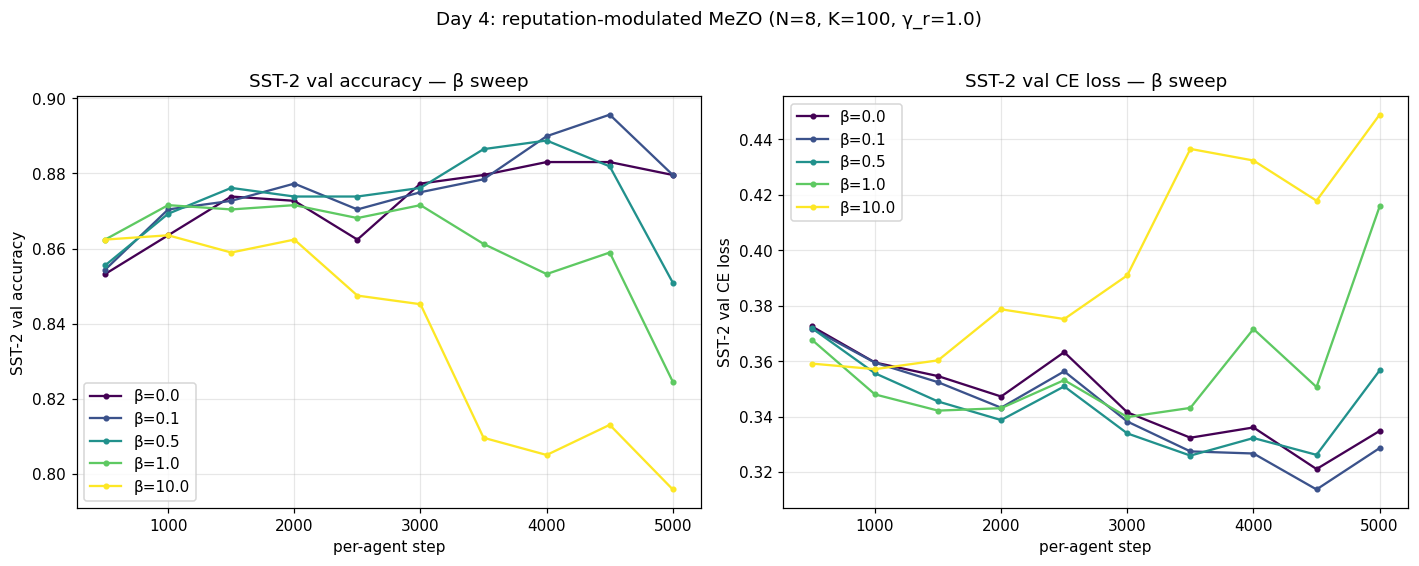

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, key, ylabel in [
    (axes[0], 'eval_acc',  'SST-2 val accuracy'),
    (axes[1], 'eval_loss', 'SST-2 val CE loss'),
]:
    for name, h in runs.items():
        ax.plot(h['eval_step'], h[key], marker='o', markersize=3,
                color=colors[name], label=f"β={h['beta']}")
    ax.set_xlabel('per-agent step'); ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} — β sweep')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(
    f"Day 4: reputation-modulated MeZO (N={d['config']['n_agents']}, "
    f"K={d['config']['local_steps']}, γ_r={d['config']['gamma_r']})",
    y=1.02,
)
plt.tight_layout()

## Plot 2 — final val accuracy vs β (the headline)

E3 on the synthetic MultiWell predicted: control (symmetric `W = (1/N)·J`)
gives hit-rate 0.92 at all β; reputational `W` reaches 0.94 at β∈[1,10]
and crashes to 0.72 at β=100. The question here is whether the same shape
shows on a real LLM loss.

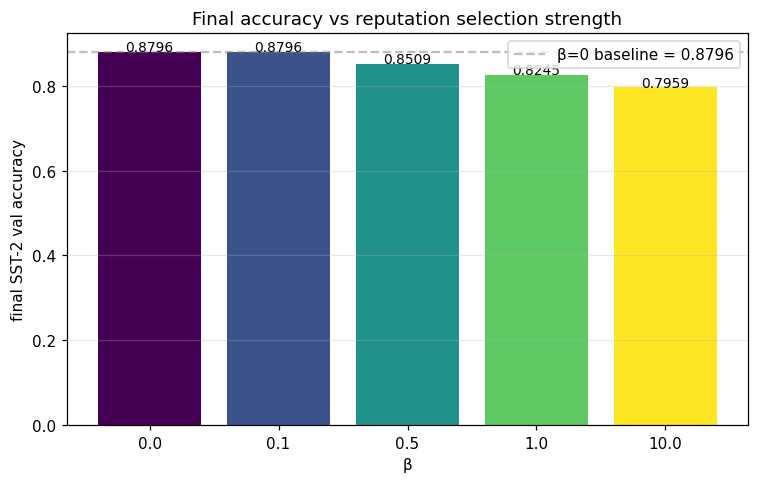

In [3]:
final_accs = [h['eval_acc'][-1] for h in runs.values()]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar([str(b) for b in betas], final_accs,
              color=[colors[k] for k in runs])
for b, acc in zip(bars, final_accs):
    ax.text(b.get_x() + b.get_width() / 2, acc + 0.002,
            f'{acc:.4f}', ha='center', fontsize=9)

# β=0 is the FedAvg-equivalent baseline by construction (all r_i stay at 1).
baseline = final_accs[0]
ax.axhline(baseline, color='gray', linestyle='--', alpha=0.5,
           label=f'β=0 baseline = {baseline:.4f}')
ax.set_xlabel('β')
ax.set_ylabel('final SST-2 val accuracy')
ax.set_title('Final accuracy vs reputation selection strength')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

## Plot 3 — reputation concentration over rounds

`max_i r_i / Σ_j r_j` per consensus round. Uniform = `1/N = 0.125` for N=8.
A cascade looks like one share monotonically climbing toward 1; a healthy
working-window run keeps the share moderately above uniform but bounded.

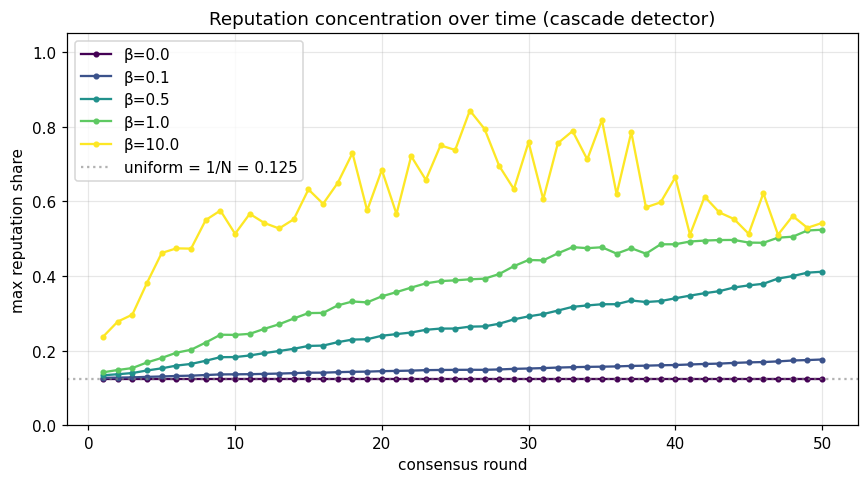

In [4]:
N = d['config']['n_agents']
fig, ax = plt.subplots(figsize=(8, 4.5))

for name, h in runs.items():
    reps = np.asarray(h['reputations'])              # (rounds, N)
    if reps.size == 0:
        continue
    shares = reps / reps.sum(axis=1, keepdims=True)
    max_share = shares.max(axis=1)
    rounds = np.arange(1, len(max_share) + 1)
    ax.plot(rounds, max_share, marker='o', markersize=3,
            color=colors[name], label=f"β={h['beta']}")

ax.axhline(1 / N, color='gray', linestyle=':', alpha=0.6,
           label=f'uniform = 1/N = {1/N:.3f}')
ax.set_xlabel('consensus round')
ax.set_ylabel('max reputation share')
ax.set_title('Reputation concentration over time (cascade detector)')
ax.set_ylim(0, 1.05)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()

## Plot 4 — per-agent probe loss at the final round

How spread are agents' losses at the end of training? Heavy spread + heavy
reputation concentration = one agent dominated. Tight spread = the swarm
stayed broadly aligned.

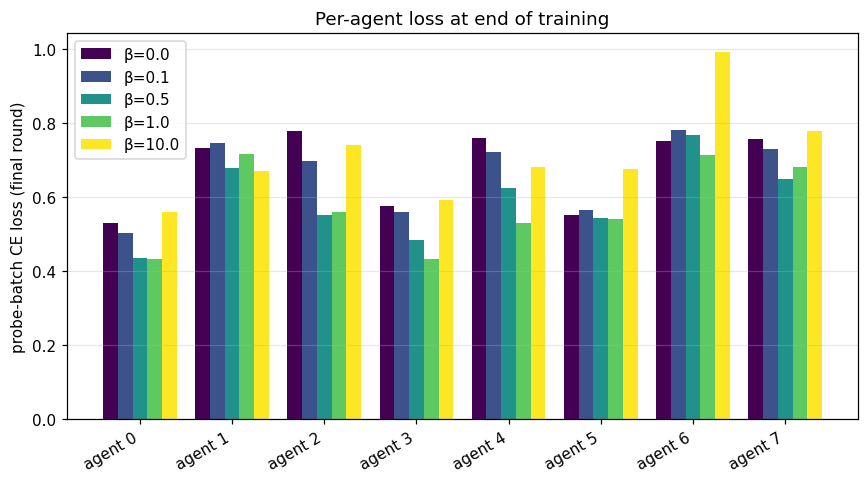

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))

x = np.arange(N)
width = 0.8 / max(len(runs), 1)
for i, (name, h) in enumerate(runs.items()):
    losses = h.get('consensus_eval_losses') or []
    if not losses:
        continue
    final = np.asarray(losses[-1])
    ax.bar(x + i * width - 0.4 + width / 2, final, width,
           color=colors[name], label=f"β={h['beta']}")

ax.set_xticks(x)
ax.set_xticklabels([f'agent {i}' for i in x], rotation=30, ha='right')
ax.set_ylabel('probe-batch CE loss (final round)')
ax.set_title('Per-agent loss at end of training')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

## Summary table

In [6]:
rows = []
for name, h in runs.items():
    reps = np.asarray(h['reputations']) if h['reputations'] else np.zeros((0, N))
    if reps.size:
        final_shares = reps[-1] / reps[-1].sum()
        max_share = float(final_shares.max())
        winner = int(final_shares.argmax())
    else:
        max_share, winner = float('nan'), -1
    rows.append({
        'β':                  h['beta'],
        'final val_acc':      h['eval_acc'][-1],
        'final val_loss':     h['eval_loss'][-1],
        'max rep share':      max_share,
        'cascade winner':     winner,
        'rounds logged':      len(reps),
    })
pd.DataFrame(rows).round(4)

,β,final val_acc,final val_loss,max rep share,cascade winner,rounds logged
0,0.0,0.8796,0.3348,0.1250,0,50
1,0.1,0.8796,0.3286,0.1760,3,50
2,0.5,0.8509,0.3566,0.4110,3,50
3,1.0,0.8245,0.4158,0.5235,3,50
4,10.0,0.7959,0.4489,0.5416,0,50
